# Part1: In-silico spatial perturbation on the PerturbFISH dataset

# Package loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import scanpy as sc
import torch
import json
from SpiderNet.model import SpiderNet_model
from SpiderNet.utils import scatter_nanmax
from scipy.stats import linregress, t
from torch_scatter import scatter_max
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, Normalize
import random
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\_utils\__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 4070


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(123)

# File Path Setup

In [3]:
file_savepath_main = "D:/CellFlowMap/PerturbFish/Results/perturb_fish/V1\SpiderNet_Result_Mode_cell_class_selfsetdim20/"
adata_list_path = file_savepath_main + 'adata_list.pkl'
SpiderNet_data_pyg_list_path = file_savepath_main + 'SpiderNet_data_pyg_list.pkl'
Factor_envir_list_path = file_savepath_main + "Factor_envir_list.pkl"
file_savepath_model_main = os.path.join(file_savepath_main, "Model/")
max_epoch = 20000
loading_LR_use_df_path = file_savepath_main + "loading_LR_use.npy"
model_config_savepath = file_savepath_model_main + "SpiderNet_model_config.json"

# Load the trained model

In [4]:
# Load the trained model
with open(model_config_savepath, "r") as f:
    model_config = json.load(f)
print(model_config)
##
model = SpiderNet_model(num_gene=int(model_config['num_gene']),
                          num_LR=int(model_config['num_LR']),
                          hidden_channels=int(model_config['hidden_channels']),
                          Factor_mode=model_config['Factor_mode'],
                          dim_intri=int(model_config['dim_intri']),
                          dim_envir=int(model_config['dim_envir']))
model.load_state_dict(torch.load(file_savepath_model_main + 'model_epoch' + str(max_epoch - 1) + '.pth'))
model.eval()

{'num_gene': 154, 'num_LR': 126, 'hidden_channels': 64, 'Factor_mode': 'cell_class', 'dim_intri': 3, 'dim_envir': 20}


SpiderNet_model(
  (dropout_fun): Dropout(p=0.1, inplace=False)
  (Relu): ReLU()
  (Sigmoid): Sigmoid()
  (enc_factor_envir_pre_receiver): Sequential(
    (0): Linear(in_features=154, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (enc_factor_envir_pre_sender): Sequential(
    (0): Linear(in_features=154, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (enc_factor_envir): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=20, bias=True)
  )
)

# Load the processed data

In [5]:
adata_list = pd.read_pickle(adata_list_path)
SpiderNet_data_pyg_list = pd.read_pickle(SpiderNet_data_pyg_list_path)
Factor_envir_list = pd.read_pickle(Factor_envir_list_path)


loading_LR_use = np.load(loading_LR_use_df_path)
loading_LR_use_df = pd.DataFrame(loading_LR_use, index=["MI" + str(i + 1) for i in range(loading_LR_use.shape[0])])

##Merge adata_list
adata_all = adata_list[0].concatenate(adata_list[1:])

# Build one-hot perturbation annotations for each cell (multi-label; '_' as separator)
# 1) tokenize the 'perturbation' field and one-hot encode
perturb_series = adata_all.obs["perturbation"].astype(str).fillna("")
perturb_annotation = perturb_series.str.get_dummies(sep="_")

# 2) drop unwanted tokens
drop_tokens = {"Control", "nan", "None", "none", ""}
cols_to_keep = [c for c in perturb_annotation.columns if c not in drop_tokens]
perturb_annotation = perturb_annotation[cols_to_keep]

# 3) ensure DataFrame aligns to obs and uses compact dtype
perturb_annotation.index = adata_all.obs.index
perturb_annotation = perturb_annotation.astype("int8")

# 4) zero-out perturbation flags for non-cancer cells
is_cancer = adata_all.obs["celltype2"].astype(str).eq("cancer").values
perturb_annotation.loc[~is_cancer, :] = 0


C:\Users\junji\AppData\Local\Temp\ipykernel_19448\727996740.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_list[0].concatenate(adata_list[1:])


# In-silico perturbation analysis (investigate T cell response to perturbed cancer cells)

In [6]:
##Specify the perturbed genes (provided from the PerturbFISH paper)
Perturbed_genes = [
    "CHUK",
    "IRAK1",
    "TRAM1",
    "LBP",
    "IRAK4",
    "PELI1",
    "TAB2",
    "MAP2K2",
    "MAP2K6",
    "IRF7",
    "MYD88"
]

## Step one: get the most related genes of each perturbed gene

In [7]:
num_top = 10
# num_top = 20
##
# LFC_threshold = -0.3
##
adata_all = adata_list[0].concatenate(adata_list[1:])
control_tumor_cellindex = np.where((adata_all.obs['celltype2'] == "cancer") * (adata_all.obs['perturbation'].astype(str) == 'nan'))[0]
meanexp_control_tumor = np.mean(adata_all[control_tumor_cellindex].X, axis=0)
gene_names = adata_all.var_names
toprelatedgene_dict = {}
for Perturbed_gene_cur in Perturbed_genes:
    perturb_tumor_cellindex = \
    np.where((np.array(adata_all.obs['celltype2']) == "cancer") * (np.array(perturb_annotation[Perturbed_gene_cur]) == 1))[0]
    meanexp_perturb_tumor = np.mean(adata_all[perturb_tumor_cellindex].X, axis=0)
    LFC_cur = np.log2(meanexp_perturb_tumor/meanexp_control_tumor)
    topgene_cur = gene_names[np.argsort(LFC_cur)][0:num_top]
    # topgene_cur = gene_names[np.where(LFC_cur < LFC_threshold)[0]]
    topgene_cur_LFC = LFC_cur[np.argsort(LFC_cur)][0:num_top]
    # topgene_cur = topgene_cur[topgene_cur_LFC < LFC_threshold]
    toprelatedgene_dict[Perturbed_gene_cur] = topgene_cur


C:\Users\junji\AppData\Local\Temp\ipykernel_19448\194100247.py:6: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_list[0].concatenate(adata_list[1:])


## Step two: get the LFC of all genes in T cell comparing the T cells near the perturbed tumor cells and the T cells not near the perturbed tumor cells

In [8]:
num_neighbors = 10
Tcell_index = np.where(adata_all.obs['celltype2'] == "T cells")[0]
neighboring_perturbedcancer_forTcell = np.zeros((len(Tcell_index), len(Perturbed_genes)))
edge_index_cur = SpiderNet_data_pyg_list[0].edge_index.cpu().numpy()

for Tcell_index_cur in Tcell_index:
    Tcell_index_cur_relative = np.where(Tcell_index == Tcell_index_cur)[0][0]
    ## get the neighboring cells
    # neighbors_all = edge_index_cur[np.where(edge_index_cur[:,0] == Tcell_index_cur)[0],1]
    neighbors_all = edge_index_cur[np.where(edge_index_cur[:, 1] == Tcell_index_cur)[0], 0]
    neighbors_celltype = adata_all.obs['celltype2'].values[neighbors_all]
    neighbors_perturbation = perturb_annotation.iloc[neighbors_all, :]
    for i, Perturbed_gene_cur in enumerate(Perturbed_genes):
        neighboring_perturbedcancer_forTcell[Tcell_index_cur_relative, i] = np.sum(neighbors_perturbation[Perturbed_gene_cur])

neighboring_perturbedcancer_forTcell_binary = (neighboring_perturbedcancer_forTcell > 0).astype(int)

LFC_Tcell_perturbcancer_dict = {}
for i, Perturbed_gene_cur in enumerate(Perturbed_genes):
    neighboring_perturbedcancer_forTcell_binary_cur = neighboring_perturbedcancer_forTcell_binary[:, i]
    Tcell_index_near_perturbcancer = Tcell_index[np.where(neighboring_perturbedcancer_forTcell_binary_cur == 1)[0]]
    Tcell_index_notnear_perturbcancer = Tcell_index[np.where(neighboring_perturbedcancer_forTcell_binary_cur == 0)[0]]
    meanexp_Tcell_near_perturbcancer = np.mean(adata_all[Tcell_index_near_perturbcancer].X, axis=0)
    meanexp_Tcell_notnear_perturbcancer = np.mean(adata_all[Tcell_index_notnear_perturbcancer].X, axis=0)
    LFC_cur = np.log2(meanexp_Tcell_near_perturbcancer / meanexp_Tcell_notnear_perturbcancer)
    LFC_cur = pd.DataFrame(LFC_cur, index=gene_names, columns=[Perturbed_gene_cur])
    LFC_Tcell_perturbcancer_dict[Perturbed_gene_cur] = LFC_cur

## Merge the LFC_Tcell_perturbcancer_dict
LFC_Tcell_perturbcancer_golden = pd.DataFrame(index=gene_names)
for Perturbed_gene_cur in Perturbed_genes:
    LFC_Tcell_perturbcancer_golden = pd.concat([LFC_Tcell_perturbcancer_golden, LFC_Tcell_perturbcancer_dict[Perturbed_gene_cur]], axis=1)


## Step three: do the in-silico knockout in cancer cell and get the LFC of all genes in T cell comparing the T cells near the perturbed tumor cells and the T cells not near the perturbed tumor cells

In [9]:
## model to device
model = model.to(device)

## Before perturbation
exp_recon = []
Factor_envir = []
for batch_index_cur in range(len(SpiderNet_data_pyg_list)):
    exp_reconcur, _, _, _, Factor_envircur, _, _, _ = model(
        SpiderNet_data_pyg_list[batch_index_cur].to(device))
    exp_recon.append(exp_reconcur.detach().cpu().numpy())
    Factor_envir.append(Factor_envircur.detach().cpu().numpy())
exp_recon = np.concatenate(exp_recon, axis=0)
exp_recon = exp_recon.astype(np.float32)
Factor_envir = np.concatenate(Factor_envir, axis=0)
Factor_envir = Factor_envir.astype(np.float32)
edge_index_all = SpiderNet_data_pyg_list[0].edge_index.cpu().numpy()
ct_edge_index_all = np.array(adata_all.obs['celltype2'].values)[edge_index_all]
cellindex_cancer = np.where(adata_all.obs['celltype2'] == "cancer")[0]

##
LFC_predicted_dict = {}
Factor_envir_dict = {}
perturbcancerTOTcell_edgerelindex_dict = {}
TcellTOTperturbcancer_edgerelindex_dict = {}
for i, Perturbed_gene_cur in enumerate(Perturbed_genes):
    ## Cancer cells perturbed by Perturbed_gene_cur
    # cancercell_perturbed_index = np.where((adata_all.obs['celltype2'] == "cancer") * (adata_all.obs['perturbation'].astype(str) == Perturbed_gene_cur))[0]
    cancercell_perturbed_index = np.where(
        (np.array(adata_all.obs['celltype2']) == "cancer") * (np.array(perturb_annotation[Perturbed_gene_cur]) == 1))[0]
    
    ## Perturbed gene
    Perturbed_gene_toprelated = toprelatedgene_dict[Perturbed_gene_cur]
    Perturbed_gene_toprelated_geneindex = np.array([np.where(adata_all.var_names == gene)[0][0] for gene in Perturbed_gene_toprelated])
    neighboring_perturbedcancer_forTcell_binary_cur = neighboring_perturbedcancer_forTcell_binary[:, i]
    Tcell_index_near_perturbcancer = Tcell_index[np.where(neighboring_perturbedcancer_forTcell_binary_cur == 1)[0]]
    Tcell_index_notnear_perturbcancer = Tcell_index[np.where(neighboring_perturbedcancer_forTcell_binary_cur == 0)[0]]
    
    ## Get predicted expression of all T cells not near perturbed cancer before and after perturbation
    ## Before perturbation
    exp_recon_Tcell_notnear_perturbcancer = exp_recon[Tcell_index_notnear_perturbcancer]
    
    ## After perturbation
    # nearcellindex_cur = [edge_index_all[:,1][np.isin(edge_index_all[:,0],Tcell_index_notnear_perturbcancer)],
    #                      edge_index_all[:,0][np.isin(edge_index_all[:,1],Tcell_index_notnear_perturbcancer)]]
    # nearcellindex_cur = np.hstack(nearcellindex_cur)
    nearcellindex_cur = edge_index_all[:, 0][np.isin(edge_index_all[:, 1], Tcell_index_notnear_perturbcancer)]
    nearcellindex_cur = np.unique(nearcellindex_cur)
    nearcellindex_cancer_cur = np.intersect1d(nearcellindex_cur, cellindex_cancer)
    
    SpiderNet_data_pyg_list_perturbed = SpiderNet_data_pyg_list.copy()
    for batch_index_cur in range(len(SpiderNet_data_pyg_list_perturbed)):
        ## Set the expression of Perturbed_gene_toprelated_geneindex in nearcellindex_cancer_cur to 0
        # SpiderNet_data_pyg_list_perturbed[batch_index_cur].x[
        #     nearcellindex_cancer_cur[:, None], Perturbed_gene_toprelated_geneindex
        # ] = 0
        ## Or
        ## Replace cancer cell expression using perturbed cancer cells
        sampling_index = np.random.choice(cancercell_perturbed_index, len(nearcellindex_cancer_cur), replace=True)
        SpiderNet_data_pyg_list_perturbed[batch_index_cur].x[
            nearcellindex_cancer_cur[:, None], :
        ] = SpiderNet_data_pyg_list[batch_index_cur].x[
            sampling_index[:, None], :
        ]
    
    exp_recon_perturb = []
    Factor_envir_perturb = []
    for batch_index_cur in range(len(SpiderNet_data_pyg_list)):
        exp_recon_perturbcur, _, _, _, Factor_envir_perturbcur, _, _, _ = model(
            SpiderNet_data_pyg_list_perturbed[batch_index_cur].to(device))
        exp_recon_perturb.append(exp_recon_perturbcur.detach().cpu().numpy())
        Factor_envir_perturb.append(Factor_envir_perturbcur.detach().cpu().numpy())
    exp_recon_perturb = np.concatenate(exp_recon_perturb, axis=0)
    exp_recon_perturb = exp_recon_perturb.astype(np.float32)
    Factor_envir_perturb = np.concatenate(Factor_envir_perturb, axis=0)
    Factor_envir_perturb = Factor_envir_perturb.astype(np.float32)
    
    Factor_envir_dict[Perturbed_gene_cur] = Factor_envir_perturb
    exp_recon_Tcell_notnear_perturbcancer_perturb = exp_recon_perturb[Tcell_index_notnear_perturbcancer]
    mean_exp_recon_Tcell_notnear_perturbcancer_perturb = np.mean(exp_recon_Tcell_notnear_perturbcancer_perturb, axis=0)
    mean_exp_recon_Tcell_notnear_perturbcancer = np.mean(exp_recon_Tcell_notnear_perturbcancer, axis=0)
    
    ## LFC
    LFC_predicted_cur = np.log2(mean_exp_recon_Tcell_notnear_perturbcancer_perturb / mean_exp_recon_Tcell_notnear_perturbcancer)
    LFC_predicted_cur = pd.DataFrame(LFC_predicted_cur, index=gene_names, columns=[Perturbed_gene_cur])
    LFC_predicted_dict[Perturbed_gene_cur] = LFC_predicted_cur
    
    ## Perturbed cancer → T cell and T cell → perturbed cancer
    perturbcancerTOTcell_edgerelindex = np.where((np.isin(edge_index_all[:,0], nearcellindex_cancer_cur)) * (np.isin(edge_index_all[:,1], Tcell_index_notnear_perturbcancer)))[0]
    TcellTOperturbcancer_edgerelindex = np.where((np.isin(edge_index_all[:,1], nearcellindex_cancer_cur)) * (np.isin(edge_index_all[:,0], Tcell_index_notnear_perturbcancer)))[0]
    perturbcancerTOTcell_edgerelindex_dict[Perturbed_gene_cur] = perturbcancerTOTcell_edgerelindex
    TcellTOTperturbcancer_edgerelindex_dict[Perturbed_gene_cur] = TcellTOperturbcancer_edgerelindex

LFC_Tcell_perturbcancer_predicted = pd.DataFrame(index=gene_names)
for Perturbed_gene_cur in Perturbed_genes:
    LFC_Tcell_perturbcancer_predicted = pd.concat([LFC_Tcell_perturbcancer_predicted, LFC_predicted_dict[Perturbed_gene_cur]], axis=1)


## Step four: Correlation between LFC from model prediction and LFC from data (golden standard)

In [10]:
corr_list = []
pvalue_list = []
for Perturbed_gene_cur in Perturbed_genes:
    LFC_golden_cur = LFC_Tcell_perturbcancer_golden[Perturbed_gene_cur]
    LFC_predicted_cur = LFC_Tcell_perturbcancer_predicted[Perturbed_gene_cur]
    common_genes = LFC_golden_cur.index.intersection(LFC_predicted_cur.index)
    ##
    # ## Spearman correlation
    from scipy.stats import spearmanr
    corr_cur, pvalue_cur = spearmanr(LFC_golden_cur.loc[common_genes], LFC_predicted_cur.loc[common_genes])
    corr_list.append(corr_cur)
    pvalue_list.append(pvalue_cur)
    ## Show scatter plot between LFC_golden_cur and LFC_predicted_cur
    plt.figure(figsize=(4, 4))
    plt.scatter(LFC_golden_cur.loc[common_genes], LFC_predicted_cur.loc[common_genes], s=5, alpha=0.5)
    plt.xlabel('Golden LFC in T cells')
    plt.ylabel('Predicted LFC in T cells')
    plt.title('Perturbed gene: ' + Perturbed_gene_cur + '\nCorrelation: ' + str(np.round(corr_cur, 3)))
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
    ## Add y=x line
    plt.plot([-3, 3], [-3, 3], color='red', linestyle='--', linewidth=0.5)
    ## Add regression line
    sns.regplot(x=LFC_golden_cur.loc[common_genes], y=LFC_predicted_cur.loc[common_genes], scatter=False, color='blue',
                line_kws={'linewidth': 0.5})
    ## Limit the range of x and y axes
    plt.xlim(min(np.min(LFC_golden_cur.loc[common_genes]), np.min(LFC_predicted_cur.loc[common_genes])),
             max(np.max(LFC_golden_cur.loc[common_genes]), np.max(LFC_predicted_cur.loc[common_genes])))
    plt.ylim(min(np.min(LFC_golden_cur.loc[common_genes]), np.min(LFC_predicted_cur.loc[common_genes])),
             max(np.max(LFC_golden_cur.loc[common_genes]), np.max(LFC_predicted_cur.loc[common_genes])))
    plt.tight_layout()
    plt.savefig(file_savepath_main + 'Scatter_Predicted_vs_Golden_LFC_in_T_cells_' + Perturbed_gene_cur + '.png', dpi=300)
    plt.close()

print(np.nanquantile(corr_list, (0, 0.2, 0.5, 0.8, 1.0)))
SpiderNet_summary = pd.DataFrame(corr_list, index=Perturbed_genes, columns=['Correlation'])


[-0.04440228  0.20856272  0.34830988  0.47193047  0.58005537]


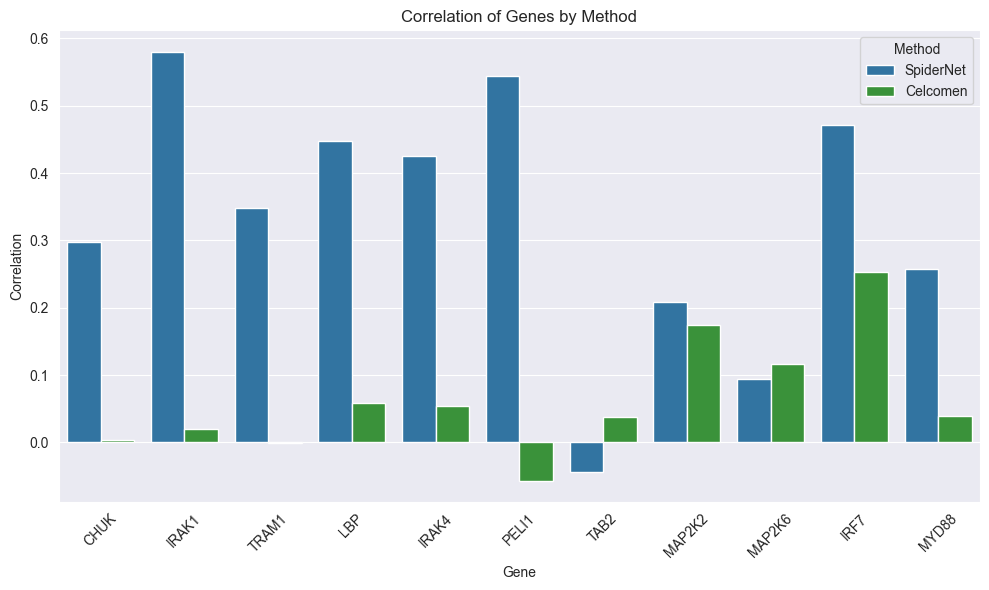

In [11]:
## Load the celcomen_summary
celcomen_summary = pd.read_csv(file_savepath_main + 'celcomen_summary.csv', index_col=0)
celcomen_summary.columns = ['Correlation']

# DataFrames for the two methods
SpiderNet_summary["Method"] = "SpiderNet"
celcomen_summary["Method"] = "Celcomen"
SpiderNet_summary["Gene"] = SpiderNet_summary.index
celcomen_summary["Gene"] = celcomen_summary.index

# Merge both DataFrames
df_long = pd.concat([SpiderNet_summary, celcomen_summary], ignore_index=True)
## Save df_long as csv
df_long.to_csv(file_savepath_main + 'Correlation_Summary_AllMethods.csv')

# Fixed color palette
palette = {
    "SpiderNet": "#1f77b4",   # blue
    "Celcomen": "#2ca02c"     # green
}

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=df_long, x="Gene", y="Correlation", hue="Method", palette=palette)
plt.xticks(rotation=45)
plt.title("Correlation of Genes by Method")
plt.tight_layout()
plt.savefig(file_savepath_main + 'Barplot_Correlation_by_Method.png', dpi=300)
plt.show()
plt.close()


## Show the change of MI strength before and after perturbation

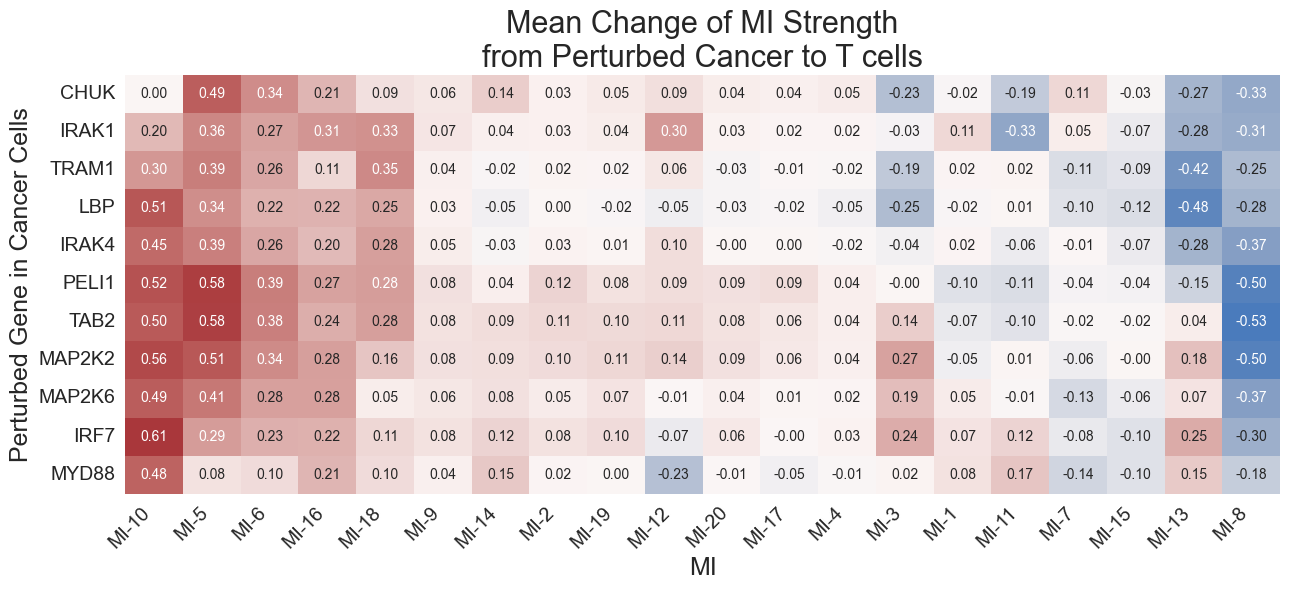

In [12]:
MI_change_perturbcancerTOTcell_df = pd.DataFrame(index=Perturbed_genes,
                                                 columns=["MI-" + str(i + 1) for i in range(Factor_envir.shape[1])])
MI_change_TcellTOTperturbcancer_df = pd.DataFrame(index=Perturbed_genes,
                                                  columns=["MI-" + str(i + 1) for i in range(Factor_envir.shape[1])])
for i, Perturbed_gene_cur in enumerate(Perturbed_genes):
    Factor_envir_perturbcur = Factor_envir_dict[Perturbed_gene_cur]
    perturbcancerTOTcell_edgerelindex_dict_cur = perturbcancerTOTcell_edgerelindex_dict[Perturbed_gene_cur]
    TcellTOTperturbcancer_edgerelindex_dict_cur = TcellTOTperturbcancer_edgerelindex_dict[Perturbed_gene_cur]
    ## perturbcancerTOTcell
    # change1 = Factor_envir_perturbcur[perturbcancerTOTcell_edgerelindex_dict_cur,:] - Factor_envir[perturbcancerTOTcell_edgerelindex_dict_cur,:]
    # MI_change_perturbcancerTOTcell_df.iloc[i,:] = np.mean(change1, axis=0)
    change1 = np.log2(np.mean(Factor_envir_perturbcur[perturbcancerTOTcell_edgerelindex_dict_cur, :], axis=0) /
                      np.mean(Factor_envir[perturbcancerTOTcell_edgerelindex_dict_cur, :], axis=0))
    MI_change_perturbcancerTOTcell_df.iloc[i, :] = change1
    ## TcellTOTperturbcancer
    # change2 = Factor_envir_perturbcur[TcellTOTperturbcancer_edgerelindex_dict_cur,:] - Factor_envir[TcellTOTperturbcancer_edgerelindex_dict_cur,:]
    # MI_change_TcellTOTperturbcancer_df.iloc[i,:] = np.mean(change2, axis=0)
    change2 = np.log2(np.mean(Factor_envir_perturbcur[TcellTOTperturbcancer_edgerelindex_dict_cur, :], axis=0) /
                      np.mean(Factor_envir[TcellTOTperturbcancer_edgerelindex_dict_cur, :], axis=0))
    MI_change_TcellTOTperturbcancer_df.iloc[i, :] = change2

## Order
MI_change_perturbcancerTOTcell_df = MI_change_perturbcancerTOTcell_df.iloc[:, np.argsort(
    np.array(np.sum(MI_change_perturbcancerTOTcell_df, axis=0)))[::-1]]
MI_change_TcellTOTperturbcancer_df = MI_change_TcellTOTperturbcancer_df.iloc[:, np.argsort(
    np.array(np.sum(MI_change_TcellTOTperturbcancer_df, axis=0)))[::-1]]

## Show the heatmap of MI_change_perturbcancerTOTcell_df
plt.figure(figsize=(13, 6))
sns.heatmap(MI_change_perturbcancerTOTcell_df.astype(float),
            fmt=".2f",
            annot=True, cmap='vlag', center=0,
            cbar=False)
plt.title('Mean Change of MI Strength\nfrom Perturbed Cancer to T cells', fontsize=22)
plt.ylabel('Perturbed Gene in Cancer Cells', fontsize=18)
plt.xlabel('MI', fontsize=18)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig(file_savepath_main + 'Heatmap_Mean_Change_of_MI_Strength_from_Perturbed_Cancer_to_T_cells.png', dpi=300)
plt.show()
plt.close()


In [13]:
##Save MI_change_TcellTOTperturbcancer_df as csv
MI_change_TcellTOTperturbcancer_df.to_csv(file_savepath_main + 'MI_change_TcellTOTperturbcancer_df.csv')
MI_change_perturbcancerTOTcell_df.to_csv(file_savepath_main + 'MI_change_perturbcancerTOTcell_df.csv')

## Check the T cell-related marker gene expression comparing based on the MI-10 receiving from cancer cells

In [14]:
gene_names = adata_all.var_names

# 1. CD8+ T cell inhibition-related markers
cd8_inhibition_markers = [
    "GZMB", "GZMA", "PRF1", "IFNG",   # cytotoxic molecules
    "ZAP70", "LCK", "LAT",            # TCR signaling
    "EOMES", "TBX21"                  # transcription factors
]
cd8_inhibition_markers = list(set(cd8_inhibition_markers).intersection(set(adata_all.var_names)))

# 2. Treg differentiation-related markers
treg_markers = [
    "FOXP3", "IL2RA", "CTLA4", "IKZF2", "TGFB1"
]
treg_markers = list(set(treg_markers).intersection(set(adata_all.var_names)))

# 3. Th1 inhibition-related markers
th1_inhibition_markers = [
    "TBX21", "IFNG", "STAT4"
]
th1_inhibition_markers = list(set(th1_inhibition_markers).intersection(set(adata_all.var_names)))

# 4. Th17 inhibition-related markers
th17_inhibition_markers = [
    "RORC", "IL17A", "IL17F", "IL23R"
]
th17_inhibition_markers = list(set(th17_inhibition_markers).intersection(set(adata_all.var_names)))

## Print the markers
print("CD8+ T cell inhibition markers:", cd8_inhibition_markers)
print("Treg induction markers:", treg_markers)
print("Th1 inhibition markers:", th1_inhibition_markers)
print("Th17 inhibition markers:", th17_inhibition_markers)

exp_obs = adata_all.X
exp_obs_Tcell = exp_obs[Tcell_index, :]

# Factor_envir
MIOI = "MI-10"
MIOI_index = int(MIOI.split("-")[1]) - 1

celltype_edge_index_all = np.array(adata_all.obs['celltype2'].values)[edge_index_all]
edge_relindex_fromcancer_to_Tcell = np.where((celltype_edge_index_all[:, 0] == "cancer") * (celltype_edge_index_all[:, 1] == "T cells"))[0]
edge_relindex_fromcancer_to_Tcell_false = np.setdiff1d(np.arange(edge_index_all.shape[0]), edge_relindex_fromcancer_to_Tcell)

Factor_envir_use = Factor_envir.copy()
Factor_envir_use[edge_relindex_fromcancer_to_Tcell_false, :] = 0

num_cell_cur = adata_all.shape[0]
MI_receiver_agg = scatter_nanmax(
    torch.tensor(Factor_envir_use).to(device),
    torch.tensor(edge_index_all)[:, 1].to(torch.int64).to(device),
    dim=0,
    dim_size=num_cell_cur
).to("cpu").numpy()

MI_receiver_agg_Tcell_MIOI = MI_receiver_agg[Tcell_index, MIOI_index]

## Fill NaN values with 0
MI_receiver_agg_Tcell_MIOI[np.isnan(MI_receiver_agg_Tcell_MIOI)] = 0


CD8+ T cell inhibition markers: ['GZMA', 'GZMB']
Treg induction markers: ['TGFB1']
Th1 inhibition markers: []
Th17 inhibition markers: []


### Plot the boxplot of marker expression vs MI-10 received by T cells

C:\Users\junji\AppData\Local\Temp\ipykernel_19448\1392025716.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_19448\1392025716.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low", "Mid", "High"], fontsize=7)


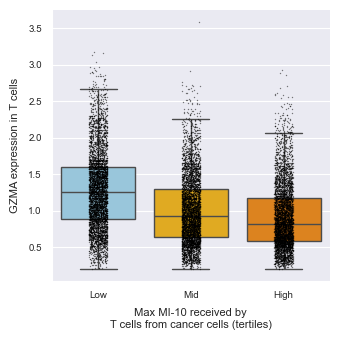

C:\Users\junji\AppData\Local\Temp\ipykernel_19448\1392025716.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\junji\AppData\Local\Temp\ipykernel_19448\1392025716.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low", "Mid", "High"], fontsize=7)


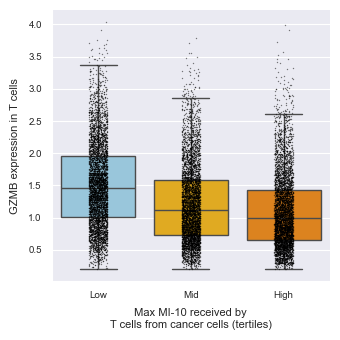

In [15]:
marker_list_use = ['GZMA', 'GZMB']
for marker_cur in marker_list_use:
    marker_cur_index = np.where(gene_names == marker_cur)[0][0]
    exp_obs_Tcell_marker_cur = exp_obs_Tcell[:, marker_cur_index]

    ## Nonzero correlation
    mask = exp_obs_Tcell_marker_cur > 0
    x = MI_receiver_agg_Tcell_MIOI[mask]
    y = exp_obs_Tcell_marker_cur[mask]

    # Group by tertiles of x
    q1, q2 = np.percentile(x, [33.3, 66.6])
    group = np.digitize(x, bins=[q1, q2])  # 0=low, 1=mid, 2=high

    # Draw boxplot
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    sns.boxplot(
        x=group, y=y, ax=ax,
        palette=["#8ecae6", "#ffb703", "#fb8500"],
        showfliers=False
    )
    sns.stripplot(
        x=group, y=y, ax=ax,
        color="black", size=1, alpha=0.5
    )

    # Set axis labels
    ax.set_xticklabels(["Low", "Mid", "High"], fontsize=7)
    ax.set_xlabel('Max ' + MIOI + ' received by\nT cells from cancer cells (tertiles)',
                  fontsize=8, labelpad=6)
    ax.set_ylabel(marker_cur + ' expression in T cells',
                  fontsize=8, labelpad=6)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Tick style
    ax.tick_params(axis='both', which='major', labelsize=7, width=0.8)

    plt.tight_layout()
    plt.savefig(
        file_savepath_main + 'Boxplot_' + marker_cur + '_expression_vs_' + MIOI + '_received_by_T_cells.png',
        dpi=600
    )
    plt.show()
    plt.close()
